<a href="https://colab.research.google.com/github/CatalinaOrtegha/3rdChallenge-TelecomX/blob/main/Modelo_Predictivo_y_Conclusiones.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Balanceo
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Optimización
from sklearn.model_selection import RandomizedSearchCV

# Métricas
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

#Preparación de los datos

In [3]:
url='https://raw.githubusercontent.com/CatalinaOrtegha/2ndChallenge_TelecomX/refs/heads/main/df_limpio_telecomX_actualizacion.json'

df=pd.read_json(url)
df

,rotacion_cliente,genero_cliente,de_tercera_edad,tiene_pareja,tiene_dependientes,meses_contrato,tipo_contrato,metodo_pago,total_gastos_por_mes,total_gastos,cuentas_diarias
0,False,Mujeres,False,True,True,9,Anual,Cheque por correo,65.60,593.30,2.19
1,False,Hombres,False,False,False,9,Mensual,Cheque por correo,59.90,542.40,2.00
2,True,Hombres,False,False,False,4,Mensual,Cheque electrónico,73.90,280.85,2.46
3,True,Hombres,True,True,False,13,Mensual,Cheque electrónico,98.00,1237.85,3.27
4,True,Mujeres,True,True,False,3,Mensual,Cheque por correo,83.90,267.40,2.80
...,...,...,...,...,...,...,...,...,...,...,...
7262,False,Mujeres,False,False,False,13,Anual,Cheque por correo,55.15,742.90,1.84
7263,True,Hombres,False,True,False,22,Mensual,Cheque electrónico,85.10,1873.70,2.84
7264,False,Hombres,False,False,False,2,Mensual,Cheque por correo,50.30,92.75,1.68
7265,False,Hombres,False,True,True,67,Bienal,Cheque por correo,67.85,4627.65,2.26


In [4]:
X = df.drop("rotacion_cliente", axis=1)
y = df["rotacion_cliente"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [6]:
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

In [7]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

In [8]:
pipeline_lr = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("classifier", LogisticRegression(max_iter=1000))
])

#Modelo Predictivo

In [9]:
param_dist_lr = {
    "classifier__C": np.logspace(-3, 3, 50),
    "classifier__penalty": ["l2"],
    "classifier__solver": ["lbfgs"]
}

In [10]:
random_search_lr = RandomizedSearchCV(
    pipeline_lr,
    param_distributions=param_dist_lr,
    n_iter=20,
    cv=5,
    scoring="roc_auc",
    random_state=42,
    n_jobs=-1
)

random_search_lr.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               StandardScaler(),
                                                                               Index(['meses_contrato', 'total_gastos_por_mes', 'total_gastos',
       'cuentas_diarias'],
      dtype='object')),
                                                                              ('cat',
                                                                               OneHotEncoder(handle_unknown='ignore'),
                                                                               Index(['genero_cliente', 'tipo_contrato', 'metodo_pago'], dtype='object'))])),
                                             ('smote',...
       8.28642773e+00, 1.09854114e+01, 1.45634848e+01, 1.93069773e+01,
       2.55954792e+01, 3.39322177e+01, 4.49843267e+01, 5.96362332e+01,
       7.90604321e+01, 1.04811313e+02, 1.38949549e+02, 1.84206997e+02,
       2.44205309e+02, 3.23745754e+02, 4.29193426e+02, 5.68986603e+02,
       7.54312006e+02, 1.00000000e+03]),
                                        'classifier__penalty': ['l2'],
                                        'classifier__solver': ['lbfgs']},
                   random_state=42, scoring='roc_auc')

In [11]:
print("Mejores parámetros LR:")
print(random_search_lr.best_params_)

Mejores parámetros LR:
{'classifier__solver': 'lbfgs', 'classifier__penalty': 'l2', 'classifier__C': np.float64(33.9322177189533)}


In [12]:
best_lr = random_search_lr.best_estimator_

y_pred_lr = best_lr.predict(X_test)
y_prob_lr = best_lr.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_lr))
print("ROC AUC:", roc_auc_score(y_test, y_prob_lr))

              precision    recall  f1-score   support

       False       0.91      0.70      0.79      1033
        True       0.49      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.73      0.74      1407

ROC AUC: 0.8275375185716282


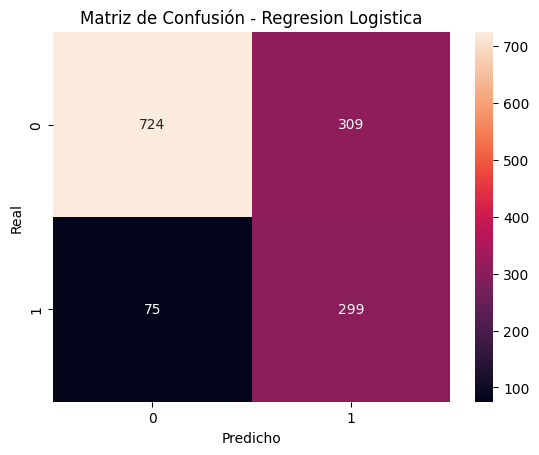

In [13]:
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Matriz de Confusión - Regresion Logistica")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.show()

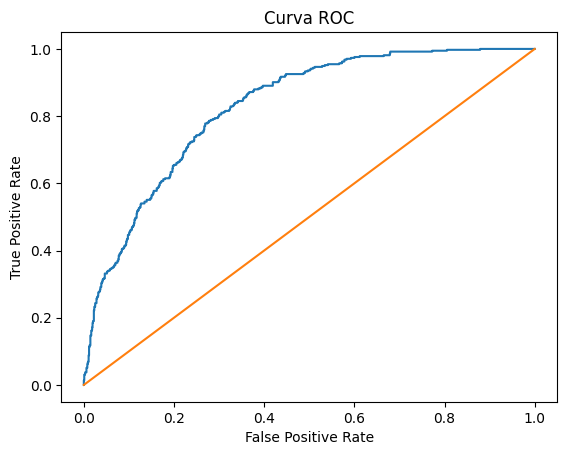

In [21]:
fpr, tpr, _ = roc_curve(y_test, y_prob_lr)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.show()

In [14]:
pipeline_rf = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("classifier", RandomForestClassifier(random_state=42))
])

In [15]:
param_dist_rf = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [None, 10, 20, 30],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4]
}

In [16]:
random_search_rf = RandomizedSearchCV(
    pipeline_rf,
    param_distributions=param_dist_rf,
    n_iter=20,
    cv=5,
    scoring="roc_auc",
    random_state=42,
    n_jobs=-1
)

random_search_rf.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               StandardScaler(),
                                                                               Index(['meses_contrato', 'total_gastos_por_mes', 'total_gastos',
       'cuentas_diarias'],
      dtype='object')),
                                                                              ('cat',
                                                                               OneHotEncoder(handle_unknown='ignore'),
                                                                               Index(['genero_cliente', 'tipo_contrato', 'metodo_pago'], dtype='object'))])),
                                             ('smote', SMOTE(random_state=42)),
                                             ('classifier',
                                              RandomForestClassifier(random_state=42))]),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'classifier__max_depth': [None, 10, 20,
                                                                  30],
                                        'classifier__min_samples_leaf': [1, 2,
                                                                         4],
                                        'classifier__min_samples_split': [2, 5,
                                                                          10],
                                        'classifier__n_estimators': [100, 200,
                                                                     300]},
                   random_state=42, scoring='roc_auc')

In [17]:
print("Mejores parámetros RF:")
print(random_search_rf.best_params_)

Mejores parámetros RF:
{'classifier__n_estimators': 100, 'classifier__min_samples_split': 2, 'classifier__min_samples_leaf': 4, 'classifier__max_depth': 10}


In [18]:
best_rf = random_search_rf.best_estimator_

y_pred_rf = best_rf.predict(X_test)
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf))
print("ROC AUC:", roc_auc_score(y_test, y_prob_rf))

              precision    recall  f1-score   support

       False       0.89      0.76      0.82      1033
        True       0.52      0.74      0.61       374

    accuracy                           0.75      1407
   macro avg       0.71      0.75      0.72      1407
weighted avg       0.79      0.75      0.76      1407

ROC AUC: 0.833970937666627


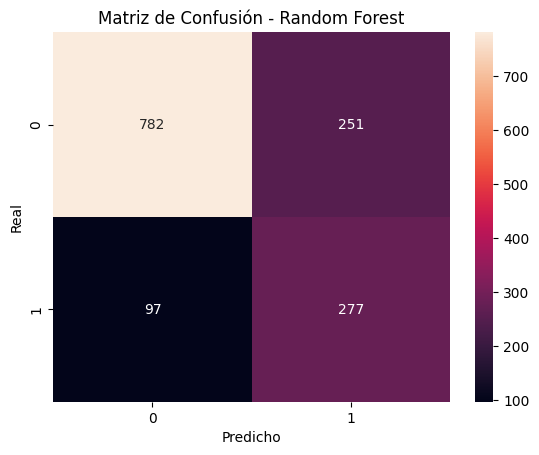

In [19]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Matriz de Confusión - Random Forest")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.show()

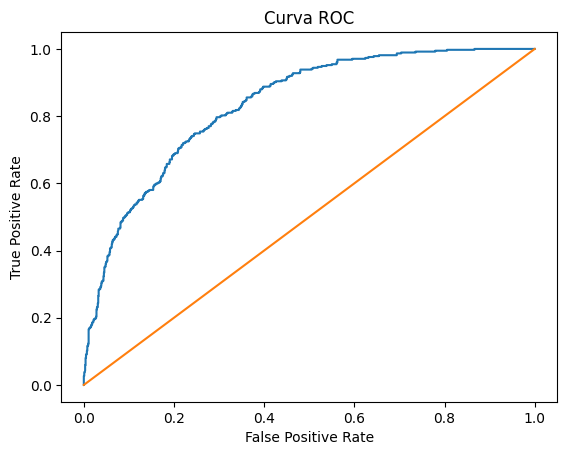

In [20]:
fpr, tpr, _ = roc_curve(y_test, y_prob_rf)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.show()

In [22]:
print("Train score RF:", best_rf.score(X_train, y_train))
print("Test score RF:", best_rf.score(X_test, y_test))

Train score RF: 0.8117333333333333
Test score RF: 0.7526652452025586


In [23]:
from sklearn.neighbors import KNeighborsClassifier

In [24]:
pipeline_knn = ImbPipeline(steps=[
    ("preprocessor", preprocessor),   # incluye StandardScaler
    ("smote", SMOTE(random_state=42)),
    ("classifier", KNeighborsClassifier())
])

In [25]:
param_dist_knn = {
    "classifier__n_neighbors": range(3, 31),
    "classifier__weights": ["uniform", "distance"],
    "classifier__metric": ["euclidean", "manhattan"]
}

In [26]:
random_search_knn = RandomizedSearchCV(
    pipeline_knn,
    param_distributions=param_dist_knn,
    n_iter=20,
    cv=5,
    scoring="roc_auc",
    random_state=42,
    n_jobs=-1
)

random_search_knn.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               StandardScaler(),
                                                                               Index(['meses_contrato', 'total_gastos_por_mes', 'total_gastos',
       'cuentas_diarias'],
      dtype='object')),
                                                                              ('cat',
                                                                               OneHotEncoder(handle_unknown='ignore'),
                                                                               Index(['genero_cliente', 'tipo_contrato', 'metodo_pago'], dtype='object'))])),
                                             ('smote', SMOTE(random_state=42)),
                                             ('classifier',
                                              KNeighborsClassifier())]),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'classifier__metric': ['euclidean',
                                                               'manhattan'],
                                        'classifier__n_neighbors': range(3, 31),
                                        'classifier__weights': ['uniform',
                                                                'distance']},
                   random_state=42, scoring='roc_auc')

In [27]:
print("Mejores parámetros KNN:")
print(random_search_knn.best_params_)

Mejores parámetros KNN:
{'classifier__weights': 'uniform', 'classifier__n_neighbors': 25, 'classifier__metric': 'euclidean'}


In [28]:
best_knn = random_search_knn.best_estimator_

y_pred_knn = best_knn.predict(X_test)
y_prob_knn = best_knn.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_knn))
print("ROC AUC:", roc_auc_score(y_test, y_prob_knn))

              precision    recall  f1-score   support

       False       0.90      0.70      0.79      1033
        True       0.49      0.79      0.60       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407

ROC AUC: 0.8255043458904286


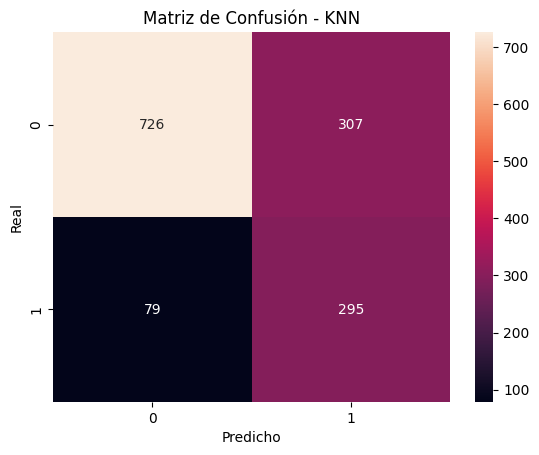

In [29]:
cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure()
sns.heatmap(cm_knn, annot=True, fmt="d")
plt.title("Matriz de Confusión - KNN")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.show()

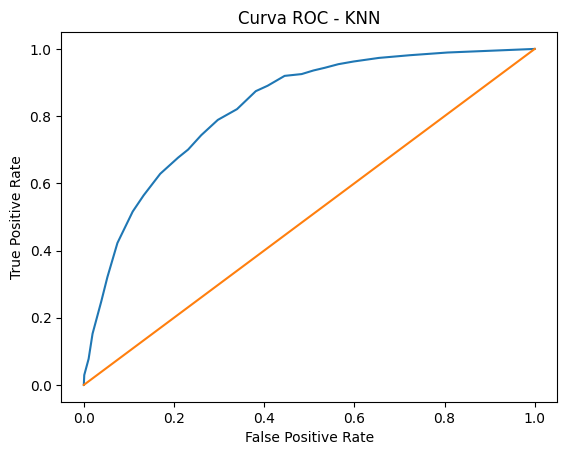

In [30]:
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)

plt.figure()
plt.plot(fpr_knn, tpr_knn)
plt.plot([0,1],[0,1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - KNN")
plt.show()

In [31]:
print("Train score KNN:", best_knn.score(X_train, y_train))
print("Test score KNN:", best_knn.score(X_test, y_test))

Train score KNN: 0.7463111111111111
Test score KNN: 0.7256574271499645


#Interpretación y conclusiones

##Análisis de la Importancia de las Variables

La Regresión Logística permitió interpretar directamente el impacto de cada variable mediante coeficientes.
Random Forest confirmó estas variables como relevantes a través de su métrica de importancia basada en reducción de impureza.
KNN mostró buen desempeño predictivo, pero limitada interpretabilidad, por lo que no fue priorizado como modelo final.

##📊 INFORME DE ANÁLISIS DE CANCELACIÓN DE CLIENTES


1️⃣ Objetivo del análisis

El objetivo del proyecto fue desarrollar modelos de machine learning capaces de predecir la cancelación de clientes (rotacion_cliente) e identificar los factores más influyentes en dicha decisión, con el fin de proponer estrategias efectivas de retención.

2️⃣ Modelos Evaluados

Se entrenaron tres modelos de clasificación:

Regresión Logística

K-Nearest Neighbors (KNN)

Random Forest

🔎 Resultados comparativos

La Regresión Logística detecta más clientes en riesgo (mayor recall).

Random Forest presenta mejor equilibrio general y mayor capacidad discriminativa (ROC AUC más alto).

KNN mostró rendimiento similar, pero menor interpretabilidad.

Debido a su mejor balance general, Random Forest fue seleccionado como modelo final.

3️⃣ Variables más influyentes en la cancelación

El análisis de coeficientes (Regresión Logística) y la importancia de variables (Random Forest) permitió identificar los factores más relevantes.

🔴 Factores que AUMENTAN la probabilidad de cancelación

1️⃣ Tipo de contrato mensual
2️⃣ Cargos mensuales elevados
3️⃣ Servicios adicionales con alto costo
4️⃣ Método de pago electrónico automático
5️⃣ Baja antigüedad

🟢 Factores que REDUCEN la probabilidad de cancelación

1️⃣ Alta antigüedad del cliente
2️⃣ Contratos a largo plazo
3️⃣ Paquetes integrales de servicios
4️⃣ Pagos automáticos bancarios estables

4️⃣ Interpretación estratégica de los factores
🎯 1. Antigüedad

Es uno de los factores más importantes.

Clientes nuevos tienen mayor probabilidad de cancelar.

🔎 Interpretación:
Existe una etapa crítica inicial donde el cliente aún no desarrolla lealtad.

🎯 2. Tipo de contrato

Los contratos mensuales presentan mayor cancelación.

🔎 Interpretación:
La falta de compromiso contractual facilita la salida.

🎯 3. Cargos mensuales altos

Clientes con facturación elevada muestran mayor probabilidad de cancelación.

🔎 Interpretación:
Sensibilidad al precio y percepción de bajo valor.

🎯 4. Métodos de pago específicos

Algunos métodos electrónicos se asocian con mayor cancelación.

🔎 Interpretación:
Puede relacionarse con perfiles más digitales y menos fidelizados.

5️⃣ Estrategias de retención propuestas

Basado en los hallazgos del modelo:

🔵 Estrategia 1: Programa de fidelización temprana

Dado que la cancelación es mayor en clientes nuevos:

Contacto proactivo en los primeros 3 meses

Encuestas de satisfacción tempranas

Beneficios exclusivos de bienvenida

Objetivo: Reducir cancelación en etapa crítica inicial.

🟢 Estrategia 2: Incentivar contratos de largo plazo

Dado que contratos mensuales presentan mayor cancelación:

Descuentos por contratos anuales

Beneficios exclusivos por permanencia

Programas de puntos acumulativos

Objetivo: Aumentar compromiso contractual.

🟡 Estrategia 3: Revisión de estructura de precios

Clientes con cargos altos cancelan más.

Ofrecer paquetes personalizados

Descuentos escalonados por permanencia

Alertas de optimización de plan

Objetivo: Reducir percepción de sobrecosto.

🔴 Estrategia 4: Segmentación predictiva

Utilizar el modelo para:

Identificar clientes en riesgo (score > threshold)

Activar campañas específicas de retención

Priorizar recursos en clientes de mayor valor

6️⃣ Conclusiones Generales

1️⃣ La cancelación puede predecirse con buen nivel de precisión (ROC AUC 0.83).
2️⃣ La antigüedad y el tipo de contrato son los factores más determinantes.
3️⃣ Random Forest mostró el mejor equilibrio entre capacidad predictiva y estabilidad.
4️⃣ Las estrategias de retención deben enfocarse especialmente en clientes nuevos y contratos mensuales.

7️⃣ Impacto potencial en negocio

Si el modelo se implementa:

Se puede reducir la tasa de cancelación anticipando clientes en riesgo.

Se optimiza el presupuesto de campañas de retención.

Se mejora la rentabilidad mediante segmentación inteligente.



Este análisis no solo permite predecir la cancelación, sino también comprender los factores estructurales que la impulsan, habilitando decisiones estratégicas basadas en datos.